# RDD matching example (sparse, semi-dense and lightglue)

## Initialize RDD

In [ ]:
from src.RDD import build
from src.RDD_helper import RDD_helper
from matplotlib import pyplot as plt
from time import time
import torch

RDD_model = build(weights='./weights/RDD-v3.pth')
RDD_model.eval()
RDD_model.to('cuda' if torch.cuda.is_available() else 'cpu')
RDD = RDD_helper(RDD_model)

/wekafs/ict/gonglinc/Documents/feature-matching/rdd_new/src/RDD.py:266: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(config['weights'], map_location='cpu

In [2]:
import cv2

def draw_matches(ref_points, dst_points, img0, img1):
    
    # Prepare keypoints and matches for drawMatches function
    keypoints0 = [cv2.KeyPoint(p[0], p[1], 1000) for p in ref_points]
    keypoints1 = [cv2.KeyPoint(p[0], p[1], 1000) for p in dst_points]
    matches = [cv2.DMatch(i,i,0) for i in range(len(ref_points))]

    # Draw inlier matches
    img_matches = cv2.drawMatches(img0, keypoints0, img1, keypoints1, matches, None,
                                  matchColor=(0, 255, 0), flags=2)

    return img_matches


def draw_points(points, img):
    for p in points:
        cv2.circle(img, (int(p[0]), int(p[1])), 2, (0, 255, 0), -1)
        
    return img


## Matching example - Sparse

In [27]:
#Load some example images
im0 = cv2.imread('./assets/507.png')
im1 = cv2.imread('./assets/image_000053.jpg')

In [28]:
start = time()
mkpts_0, mkpts_1, conf = RDD.match(im0, im1, resize=1024)
print(f"Found {len(mkpts_0)} matches in {time()-start:.2f} seconds")

Found 59 matches in 1.15 seconds


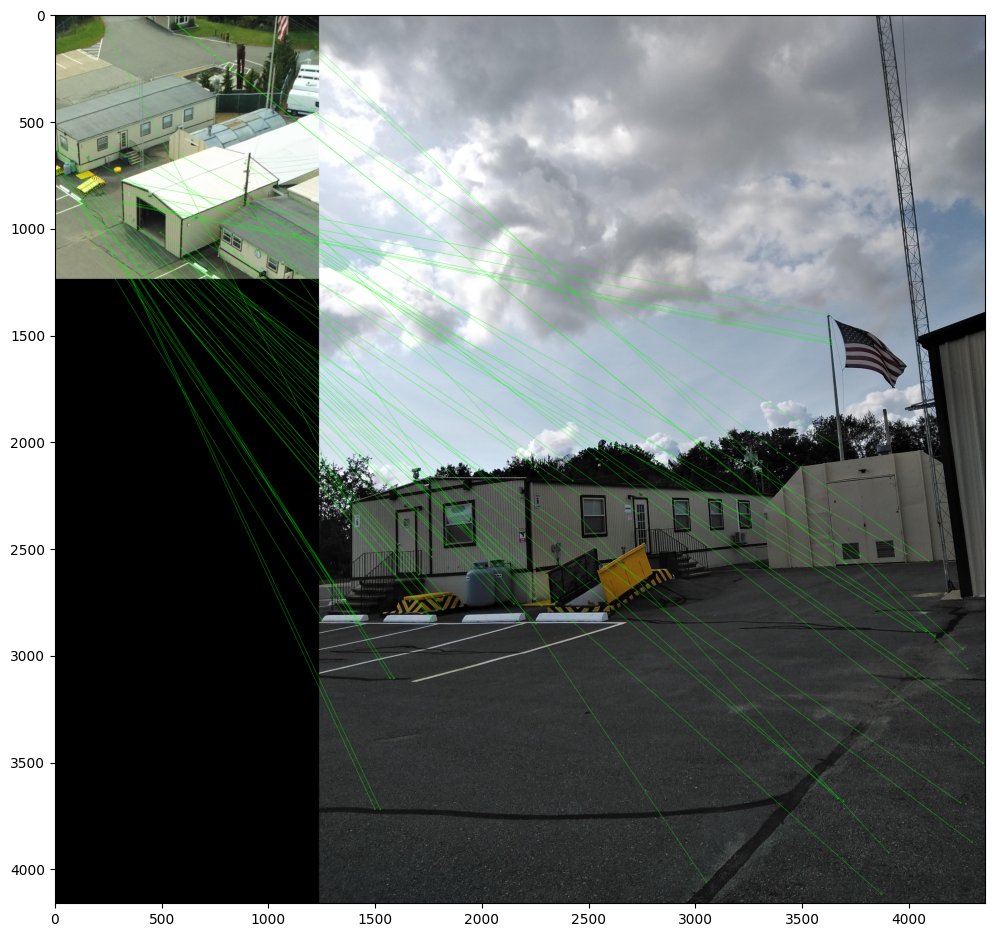

(<matplotlib.image.AxesImage at 0x1553c45f1570>, None)

In [29]:
canvas = draw_matches(mkpts_0, mkpts_1, im0, im1)
plt.figure(figsize=(12,12))
plt.imshow(canvas[..., ::-1]), plt.show()

## Matching example - Semi-Dense

In [30]:
start = time()
mkpts_0, mkpts_1, conf = RDD.match_dense(im0, im1, resize=1024, anchor='mnn')
print(f"Found {len(mkpts_0)} matches in {time()-start:.2f} seconds")

Found 59 matches in 0.99 seconds


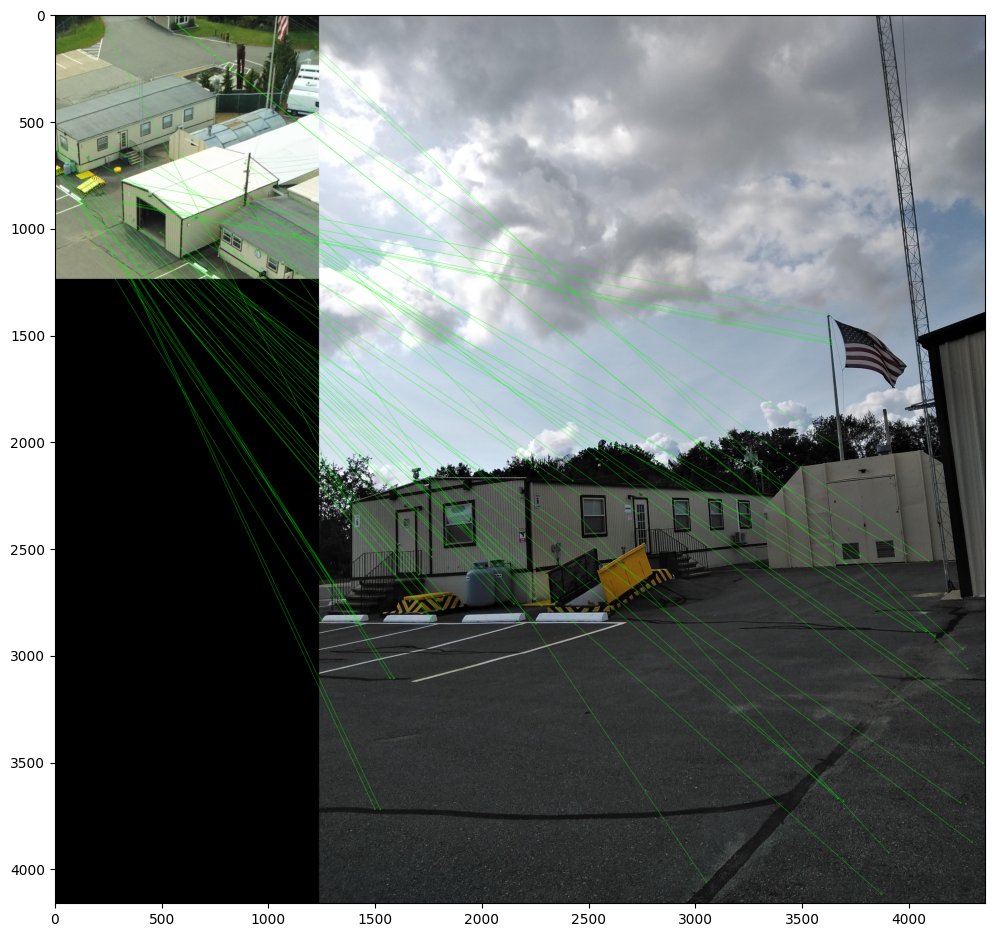

(<matplotlib.image.AxesImage at 0x1553c44866b0>, None)

In [31]:
canvas = draw_matches(mkpts_0, mkpts_1, im0, im1)
plt.figure(figsize=(12,12))
plt.imshow(canvas[..., ::-1]), plt.show()

## Matching example - LightGlue

In [34]:
start = time()
mkpts_0, mkpts_1, conf = RDD.match_lg(im0, im1, resize=1024)
print(f"Found {len(mkpts_0)} matches in {time()-start:.2f} seconds")

Found 174 matches in 1.11 seconds


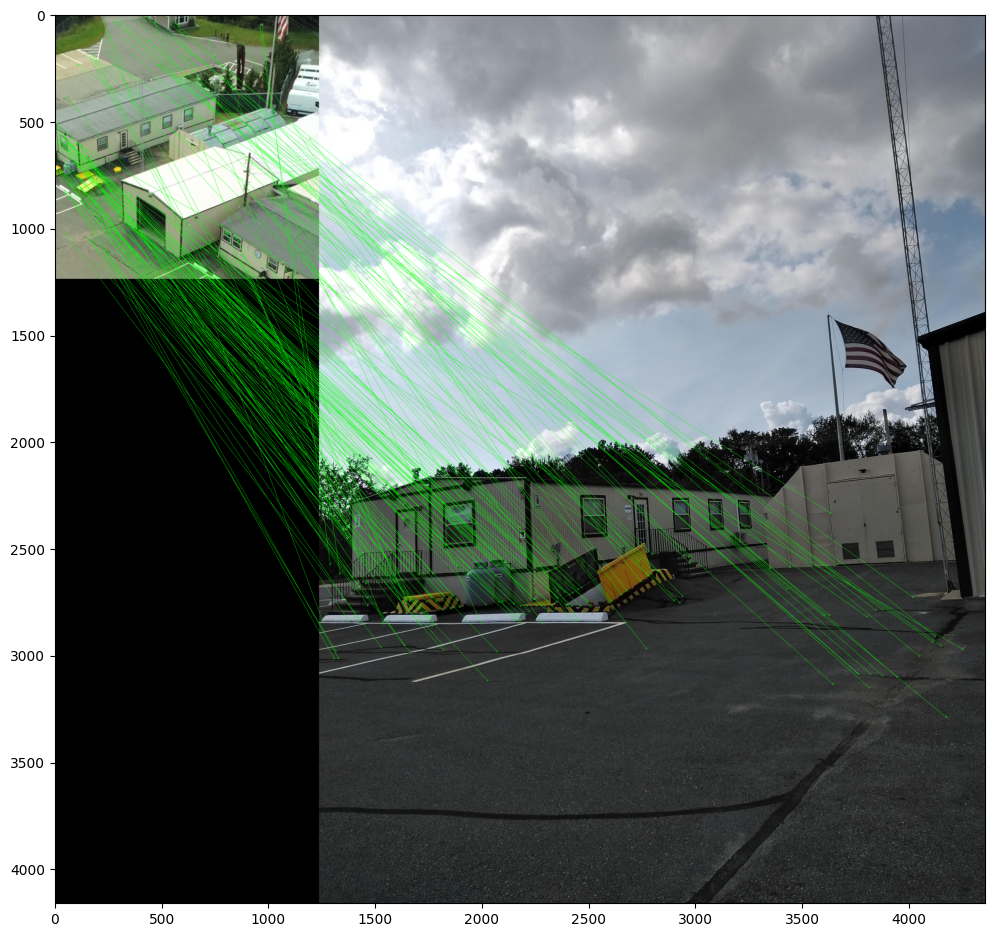

(<matplotlib.image.AxesImage at 0x1553c43a2fb0>, None)

In [35]:
canvas = draw_matches(mkpts_0, mkpts_1, im0, im1)
plt.figure(figsize=(12,12))
plt.imshow(canvas[..., ::-1]), plt.show()

## Matching example - Using differnt detector + RDD descriptor

In [ ]:
start = time()
mkpts_0, mkpts_1, conf = RDD.match_3rd_party(im0, im1, resize=1024, model='aliked')
print(f"Found {len(mkpts_0)} matches in {time()-start:.2f} seconds")

# take a look at folder third_party, RDD/RDD.py and RDD/RDD_helper.py 
# if you want to configure your own detector